In [8]:
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten # GRU,
from tensorflow.keras.models import Sequential

In [19]:
import pandas as pd

df = pd.read_csv('crypto_cleaned.csv')

print(f' Row and Column # in the dataset: {df.shape}')
print(f'The column names: {df.columns}')


 Row and Column # in the dataset: (824600, 14)
The column names: Index(['slug', 'symbol', 'name', 'date', 'ranknow', 'open', 'high', 'low',
       'close', 'volume', 'market', 'close_ratio', 'spread',
       'volume_missing_flag'],
      dtype='object')


In [20]:
df['date'].min(), df['date'].max()

('2013-04-28', '2018-11-30')

In [21]:
df.dtypes, df['date'].dtype

(slug                    object
 symbol                  object
 name                    object
 date                    object
 ranknow                  int64
 open                   float64
 high                   float64
 low                    float64
 close                  float64
 volume                 float64
 market                 float64
 close_ratio            float64
 spread                 float64
 volume_missing_flag       bool
 dtype: object,
 dtype('O'))

In [ ]:
# from tensorflow.keras.layers import GRU
# model = Sequential([
#     GRU(50, return_sequences=True, input_shape=(time_steps, features)),
#     GRU(50),
#     Dense(1, activation='linear')
# ])
# model.compile(optimizer='adam', loss='mse')

In [ ]:
# import numpy as np
# # import tensorflow as tf
# # from tensorflow.keras.models import Sequential
# # from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
# # from sklearn.preprocessing import MinMaxScaler
# # import matplotlib.pyplot as plt

# # Step 1: Generate synthetic time-series data
# def generate_time_series(n_steps):
#     time = np.arange(n_steps)
#     series = np.sin(0.1 * time) + np.random.randn(n_steps) * 0.1  # Sine wave with noise
#     return series

# # Parameters
# n_steps = 1000
# window_size = 20  # Number of time steps in each input window
# forecast_horizon = 1  # Predict the next single value

# # Generate data
# data = generate_time_series(n_steps)
# data

In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Assume df is your pandas DataFrame
# Example: df = pd.read_csv('your_data.csv')
# df.columns = ['date', 'feature1', 'feature2', ..., 'feature12', 'target']

# Step 1: Convert date column to datetime and sort by date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df['spread'] = df['high'] - df['low']
df['return'] = (df['close'] - df['open']) / df['open']
df['ma_3'] = df['close'].rolling(window=3).mean()
df['ma_7'] = df['close'].rolling(window=7).mean()
df['ma_14'] = df['close'].rolling(window=14).mean()
df['volatility_7'] = df['close'].rolling(window=7).std()
df['close_lag1'] = df['close'].shift(1)
df['volume_lag1'] = df['volume'].shift(1)

# Target: next day's close price
df['target'] = df['close'].shift(-1)

df = df.dropna()
df.head()

,slug,symbol,name,date,ranknow,open,high,low,close,volume,...,spread,volume_missing_flag,return,ma_3,ma_7,ma_14,volatility_7,close_lag1,volume_lag1,target
89418,peercoin,PPC,Peercoin,2013-04-30,159,0.407066,0.436540,0.363140,0.37530,0.0,...,0.073400,True,-0.078036,3.018433,2.310550,21.833376,2.028685,4.30000,0.0,1.500000
185146,namecoin,NMC,Namecoin,2013-04-30,371,1.320000,1.720000,1.270000,1.50000,0.0,...,0.450000,True,0.136364,2.058433,2.423452,12.354091,1.945010,0.37530,0.0,4.310000
307070,novacoin,NVC,Novacoin,2013-04-30,700,4.560000,4.690000,4.200000,4.31000,0.0,...,0.490000,True,-0.054825,2.061767,2.849166,12.358376,1.991364,1.50000,0.0,0.674150
386340,terracoin,TRC,Terracoin,2013-04-30,895,0.707040,0.711892,0.647944,0.67415,0.0,...,0.063948,True,-0.046518,2.161383,2.278330,12.327244,1.954801,4.31000,0.0,139.000000
2,bitcoin,BTC,Bitcoin,2013-04-30,1,144.000000,146.930000,134.050000,139.00000,0.0,...,12.880000,True,-0.034722,47.994717,22.077064,22.209609,51.588627,0.67415,0.0,0.322892


In [ ]:
# Step 2: Extract features and target
# Replace 'target' with your actual target column name
X = df.drop(columns=['date', 'slug','volume_missing_flag','symbol','name','target'])  # Drop date and target

# (slug                    object
#  symbol                  object
#  name                    object
#  date                    object
#  ranknow                  int64
#  open                   float64
#  high                   float64
#  low                    float64
#  close                  float64
#  volume                 float64
#  market                 float64
#  close_ratio            float64
#  spread                 float64
#  volume_missing_flag       bool

y = df['target'].values  # Target variable
# Step 3: Handle missing values (if any)
#X = X.fillna(X.mean())  # Fill missing values with column means
# y = np.where(np.isnan(y), np.nanmean(y), y)  # Fill missing target values
X.describe()

,ranknow,open,high,low,close,volume,market,close_ratio,spread,return,ma_3,ma_7,ma_14,volatility_7,close_lag1,volume_lag1
count,824586.000000,8.245860e+05,8.245860e+05,8.245860e+05,8.245860e+05,8.245860e+05,8.245860e+05,824586.000000,8.245860e+05,824586.000000,8.245860e+05,824586.000000,824586.000000,824586.000000,8.245860e+05,8.245860e+05
mean,927.699154,3.565611e+02,4.152492e+02,3.065917e+02,3.539712e+02,9.811750e+06,1.971274e+08,0.458632,1.086575e+02,0.088306,3.539141e+02,353.889951,353.880996,931.402879,3.538993e+02,9.811750e+06
std,549.407962,1.362311e+04,1.660363e+04,1.141723e+04,1.352741e+04,1.966180e+08,3.821654e+09,0.325088,6.642640e+03,42.386925,7.808779e+03,5117.431336,3624.706523,13493.125152,1.352726e+04,1.966180e+08
min,1.000000,7.100000e-09,7.600000e-09,3.000000e-09,7.100000e-09,0.000000e+00,1.000000e+00,-1.000000,0.000000e+00,-0.999853,1.766654e-07,0.000047,0.000210,0.000000,7.100000e-09,0.000000e+00
25%,418.000000,2.505000e-03,2.827000e-03,2.218000e-03,2.498000e-03,1.720000e+02,1.032932e+05,0.163800,3.572500e-04,-0.060860,2.233000e-02,0.078763,0.171437,0.124876,2.498000e-03,1.720000e+02
50%,959.000000,2.541300e-02,2.837900e-02,2.280550e-02,2.533050e-02,4.010000e+03,1.003674e+06,0.431200,3.953000e-03,-0.002427,1.368703e-01,0.347152,0.736274,0.613477,2.533050e-02,4.010000e+03
75%,1418.000000,2.384655e-01,2.633735e-01,2.159180e-01,2.377877e-01,1.141858e+05,9.338160e+06,0.742300,3.591175e-02,0.050747,7.863940e-01,1.957349,5.863900,4.046573,2.377877e-01,1.141858e+05
max,2039.000000,2.298390e+06,2.926100e+06,2.030590e+06,2.300740e+06,2.384090e+10,3.265025e+11,1.000000,1.770563e+06,34513.333333,7.715892e+05,330706.495746,165354.435682,869597.845066,2.300740e+06,2.384090e+10


In [63]:
len(y), X.shape

(824586, (824586, 16))

In [ ]:
df[df['close_ratio']>0].head(20)

In [79]:
# Step 4: Normalize/scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Create sequences for GRU
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X_scaled[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 7  # Number of time steps in each sequence
X_seq, y_seq = create_sequences(X_scaled, y, time_steps)

In [80]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

In [78]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((659663, 7, 16), (164916, 7, 16), (659663,), (164916,))

In [81]:
model = Sequential([
    GRU(units=64, return_sequences=True, input_shape=(time_steps, X_train.shape[2])),
    # Dropout(0.2),
    GRU(units=32),
    # Dropout(0.2),
    Dense(units=16, activation='relu'),
    Dense(units=1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Summary of the model
model.summary()

/opt/miniconda3/envs/dsi_xz/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_8 (GRU)                     │ (None, 7, 64)          │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,697 (100.38 KB)

 Trainable params: 25,697 (100.38 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
16492/16492 ━━━━━━━━━━━━━━━━━━━━ 203s 12ms/step - loss: 279459616.0000 - mae: 533.1373 - val_loss: 183844688.0000 - val_mae: 747.6776
Epoch 2/30
16492/16492 ━━━━━━━━━━━━━━━━━━━━ 210s 13ms/step - loss: 267188400.0000 - mae: 676.4753 - val_loss: 183866944.0000 - val_mae: 657.6550
Epoch 3/30
16492/16492 ━━━━━━━━━━━━━━━━━━━━ 203s 12ms/step - loss: 265704976.0000 - mae: 663.9680 - val_loss: 183807376.0000 - val_mae: 815.9821
Epoch 4/30
16492/16492 ━━━━━━━━━━━━━━━━━━━━ 242s 15ms/step - loss: 210834560.0000 - mae: 673.7525 - val_loss: 183832704.0000 - val_mae: 707.0294
Epoch 5/30
16492/16492 ━━━━━━━━━━━━━━━━━━━━ 198s 12ms/step - loss: 244023792.0000 - mae: 702.6432 - val_loss: 183832576.0000 - val_mae: 706.1458
Epoch 6/30
16492/16492 ━━━━━━━━━━━━━━━━━━━━ 210s 13ms/step - loss: 201436640.0000 - mae: 649.6868 - val_loss: 183808544.0000 - val_mae: 886.0777
Epoch 7/30
16492/16492 ━━━━━━━━━━━━━━━━━━━━ 12360s 749ms/step - loss: 275525376.0000 - mae: 799.2335 - val_loss: 183836032.0000 - 

In [83]:
# Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")


# Make predictions
predictions = model.predict(X_test)

Test Loss: 18587514.0000, Test MAE: 528.9998
5154/5154 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step


In [70]:
predictions.min(), predictions.max()

(np.float32(376.8473), np.float32(407.4323))

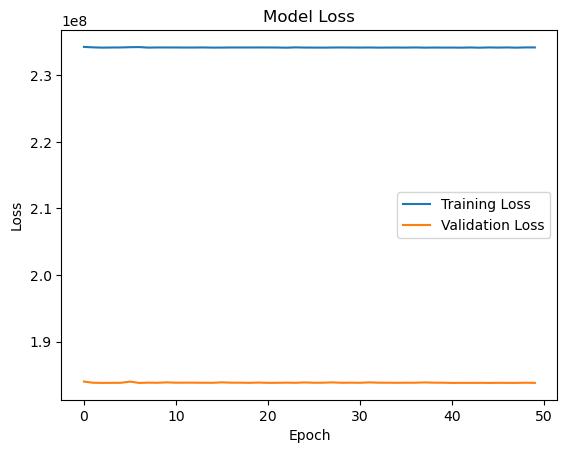

In [53]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [54]:
import pickle

# Assuming 'model' is your trained machine learning model
# Save the model to a file
with open('gru_model_1.pkl', 'wb') as file:
    pickle.dump(model, file)

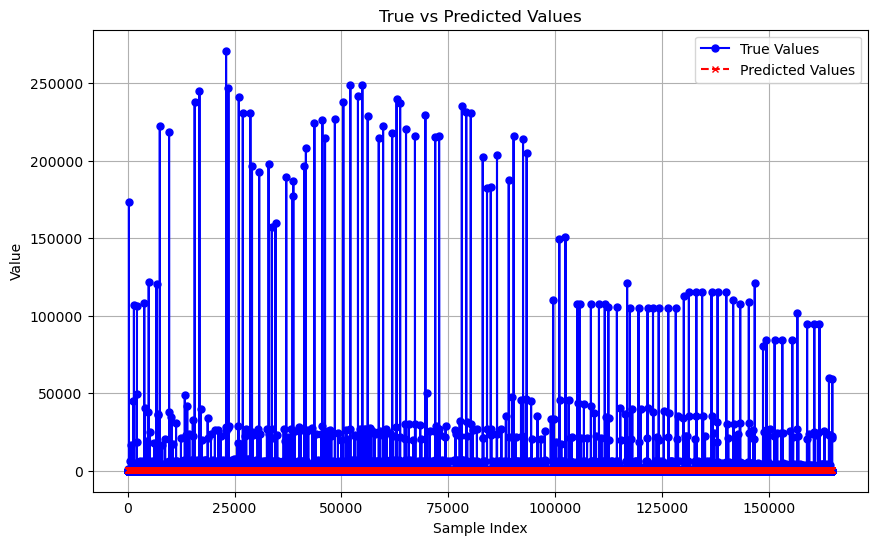

In [55]:
# import matplotlib.pyplot as plt
# import numpy as np

# Assuming y_test is the true values and predictions is the predicted values
# If predictions is a 2D array with shape (n_samples, 1), flatten it
predictions = predictions.flatten() if predictions.ndim > 1 else predictions

# Create an index for the x-axis (e.g., sample indices)
indices = np.arange(len(y_test))

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(indices, y_test, label='True Values', color='blue', marker='o', linestyle='-', markersize=5)
plt.plot(indices, predictions, label='Predicted Values', color='red', marker='x', linestyle='--', markersize=5)
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('True vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()